# Laborator 11 -> Karate

Se cere identificarea comunităților existente într-o rețea folosind:
- un algoritm predefinit intr-o biblioteca specializata (e.g. networkx, gephi, altele);
- un algoritm evolutiv.

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from networkx.linalg.graphmatrix import adjacency_matrix
from pyvis.network import Network

### Vizualizarea retelei

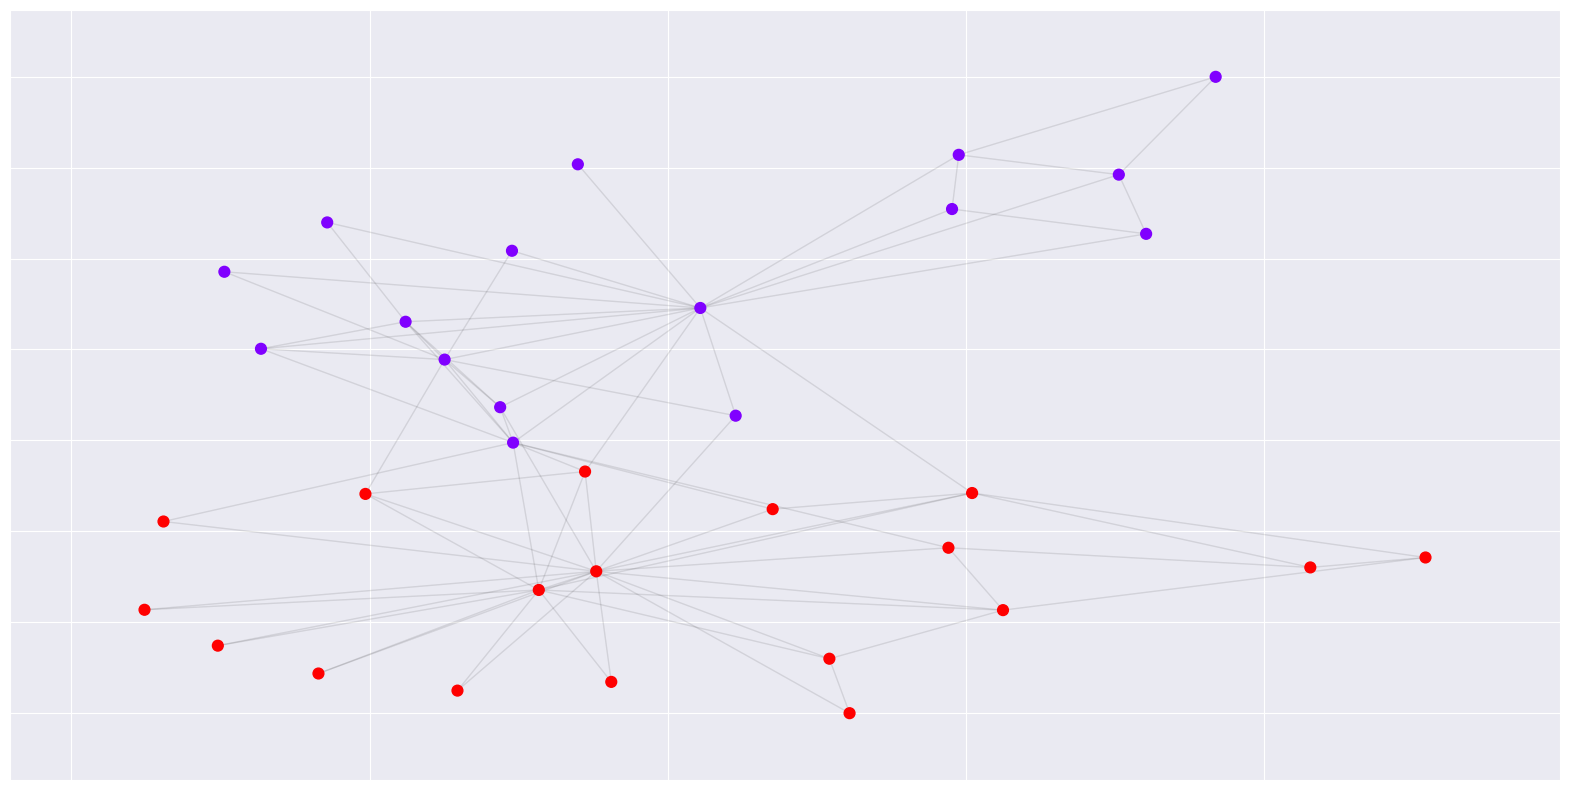

In [42]:
# graful care descrie reteaua
# trebuie mentionat ca se citesc id-urile -> by deafult, se citesc labeluri (care in setul de date "karate.gml" nu exista)
G = nx.read_gml("../../given_networks/karate/karate.gml", label='id', destringizer=int)

labelList = list(G.nodes())
adjacencyMatrix = nx.to_numpy_array(G).tolist()
adjacencyMatrix = [[int(x) for x in row] for row in adjacencyMatrix]

communities = [0] * len(labelList)


# se salveaza apartenenta fiecarui nod la o comunitate
with open("../../given_networks/karate/classLabelkarate.txt", "r") as f:
    for linie in f:
        date = linie.strip().split()
        if len(date) == 2:
            id = int(date[0])
            community = int(date[1])

            #name = labelList[id_text-1]
            G.nodes[id]["group"] = community
            communities[id-1] = community

dataCommunities = []

with open("../../given_networks/karate/real.dat", "r") as f:
    for linie in f:
        nodes = [int(x) for x in linie.strip().split()]
        dataCommunities.append(nodes)

pos = nx.spring_layout(G,seed = 42)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

Evaluarea modularity

In [43]:
def modularity(communities, adjacencyMatrix,differentiaryFactor):
    m = sum(sum(row) for row in adjacencyMatrix) / 2
    Q = 0
    for community in communities:
        for i in community:
            for j in community:
                # nodurile sunt numerotate de la 1, dar in matrice sunt stocate incepand cu pozitia 0 (caz in care differentiaryFactor este 1 -> pentru cod propriu, nu va exista aceasta diferenta)
                ki = sum(adjacencyMatrix[i-differentiaryFactor])
                kj = sum(adjacencyMatrix[j-differentiaryFactor])

                Q += adjacencyMatrix[i-differentiaryFactor][j-differentiaryFactor] - ki * kj / (2 * m)

    Q *= 1/(2*m)
    return Q

In [44]:
print(modularity(dataCommunities, adjacencyMatrix,1))

0.37146614069690825


### Determinarea comunitatilor cu tool

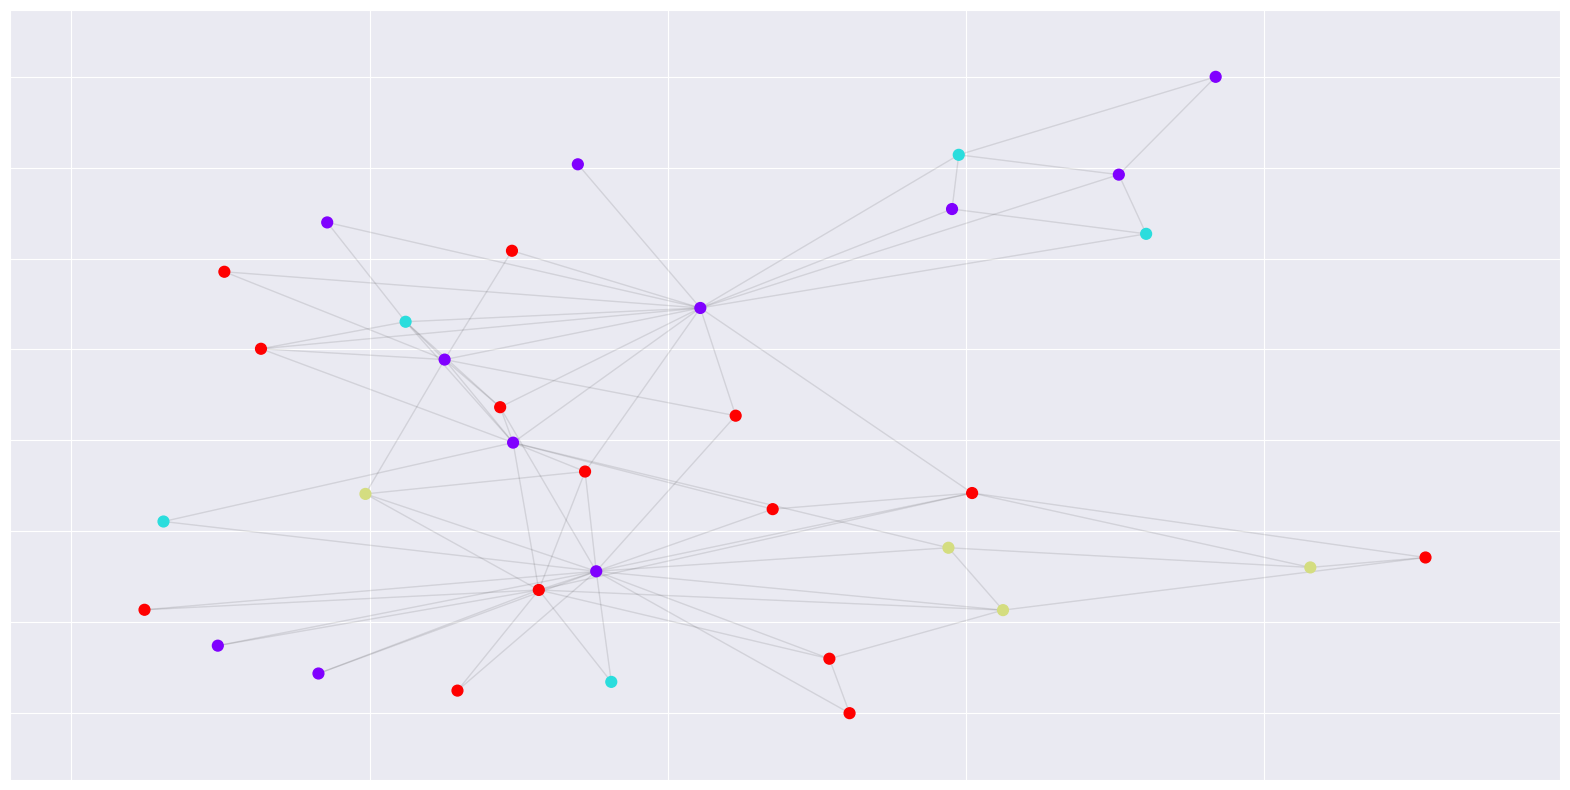

In [45]:
from networkx.algorithms import community

# se introduce si param seed, deoarece, in cadrul algoritmului exista acea comp. aleatorie
# se vor returna seturi (comunitatile) ce contin id-urile
communityTOOL = community.louvain_communities(G, seed=11)

# reprezentarea numerica
nameToId = {name: idx for idx, name in enumerate(G.nodes())}
communityTOOLNumerical = []

for nodeSet in communityTOOL:
    # se transforma fiecare nume in id-ul sau
    currentCommunity = [nameToId[nodeName] for nodeName in nodeSet]
    communityTOOLNumerical.append(currentCommunity)

communities = [0] * len(labelList)
for idComunity, com in enumerate(communityTOOLNumerical):
    for nod in com:
        #G.nodes[nod]['group'] = idComunity
        communities[nod-1] = idComunity


pos = nx.spring_layout(G,seed = 42)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [46]:
print(modularity(communityTOOL, adjacencyMatrix,1))

0.41510519395134693


### Determinarea comunitatilor folosind cod propriu

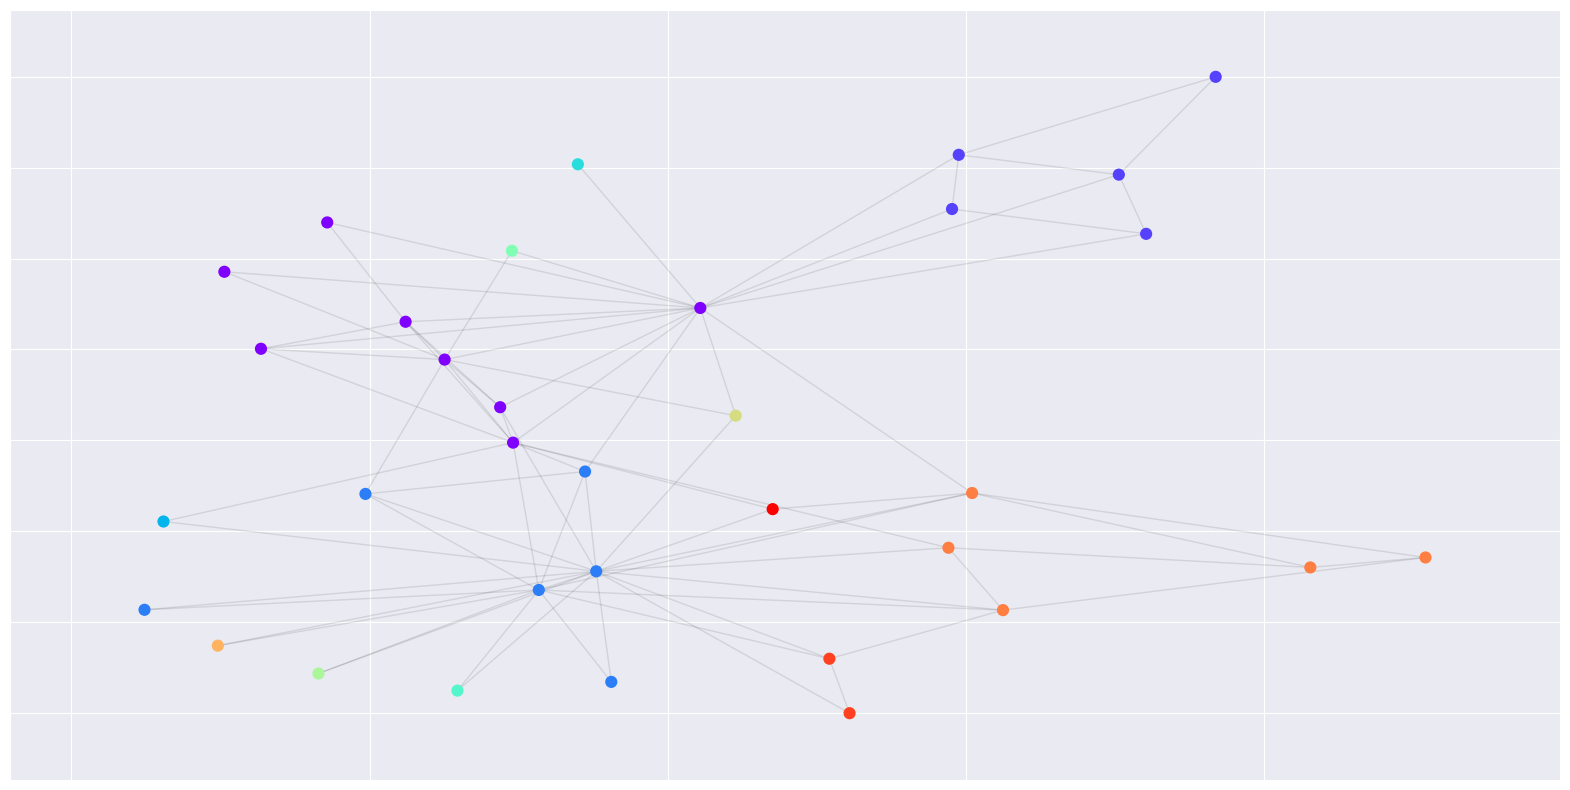

In [47]:
from fitnessModularity import fitnessFunction
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.06
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
nodesList = list(G.nodes())
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        nodeName = nodesList[nodeIndex]
        G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId


pos = nx.spring_layout(G,seed = 42)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [48]:
print(modularity(decodedBest, adjacencyMatrix,0))

0.301610782380013
